<a href="https://colab.research.google.com/github/cailyx/polyadenylation/blob/main/draft_polya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

here we study the competitition between the looped state and the linear state as we grow the polyA tail to try to understand experimental observations- the drop-off point in polyadenylation rate, salt and PEG effects on tail length and possibly rate, and when a polyA and PABP-coated polyA are in a circled/globuled or extended/linear form. the more general idea to be studied is that of a growing strand of RNA controlling its own growth- can an RNA sense and respond to its length simply by physical rules that make it so?

## background
To ask the mechanical question, **what is the energy cost of bending a polymer (i.e., which is incurred upon forming a polyA loop)?,** we can treat it as a [worm-like chain](https://chem.libretexts.org/Bookshelves/Biological_Chemistry/Concepts_in_Biophysical_Chemistry_(Tokmakoff)/02%3A_Macromolecules/09%3A_Macromolecular_Mechanics/9.02%3A_Worm-like_Chain) whose behavior is described by bending stiffness (dependent on a persistence length) and a contour length (length when stretched out to what is maximally physically possible).
* this will manifest as an energy term E_bend that describes how 'bad' it is to be bending the polyA. the linked text includes an example for calculating the energy required to wrap DNA around the histone octamer in the nucleosome given persistence length and radius, which i follow.

To assign an entropy term to a "loop" conformation, we can treat the polymer as a self-avoiding walk (SAW) and ask, **how unlikely is it for 2 ends of a chain to find each other?**. [polymer loops](https://chem.libretexts.org/Bookshelves/Biological_Chemistry/Concepts_in_Biophysical_Chemistry_(Tokmakoff)/02%3A_Macromolecules/07%3A_Statistical_Description_of_Macromolecular_Structure/7.03%3A_Polymer_Loops) can be described with a configurational entropy S that depends on the size of the loop. This term alone ignores excluded volume effects.
* this will give us a (positive) entropy term S that's going to raise the energy of forming a loop. the linked text includes a derivation of the expression for S in terms of n (number of A's), and 3 constants a, b, and c for a SAW on a cubic lattice.

[Excluded volume](https://chem.libretexts.org/Bookshelves/Biological_Chemistry/Concepts_in_Biophysical_Chemistry_(Tokmakoff)/02%3A_Macromolecules/07%3A_Statistical_Description_of_Macromolecular_Structure/7.02%3A_Excluded_Volume_Effects) effects help account for the behavior of non-ideal chains. In an ideal chain, the orientational correlations between polymer segments (i.e., the same thing used to compute persistence length!) decays exponentially as we consider 2 points increasingly far apart along the countour. (the position of one end of a longer and longer floppy spaghetti gives less and less info about the position on the other end). But excluded volume effects (e.g., *arising from self-avoidance*) imagine "long-range" interactions within the chain (far apart along the contour, short range in space) and steric effects which in effect expand the volume that the polymer takes up in space. These depend on the chain, solvent, and temperature. Interestingly, if a solvent is poor enough to cancel the effects of excluded volume expansion (i.e., the polymer has to expand but it equally has to collapse away from solvent), we reach a so-called [theta point](https://en.wikipedia.org/wiki/Theta_solvent) (specified by solvent and a temperature) and will behave just as an ideal chain (i.e., which only depend on short-range properties incl. bond length, bond angles, sterically favorable rotations)!
* this will alter (decrease) our entropy term S.


## sketch
To consider a growing polyA tail we run through a range of A's and compute each energy term as well as the total energy for the polymer. We contrast this between the naked polyA RNA, using an experimentally determined persistence length value of ~2 nm, and a PABP-bound polyA tail, whose persistence length increases in proportion to the number of A's raised to some nth power (somewhat arbitrary).

globule volume is totally full at 1162 nt and 96.83333333333333 PABPs.
with arbitrary sterics factor that multiplies the 'effective' pabp volume by 5, globule volume is full at 249 nt and 20.75 PABPs.


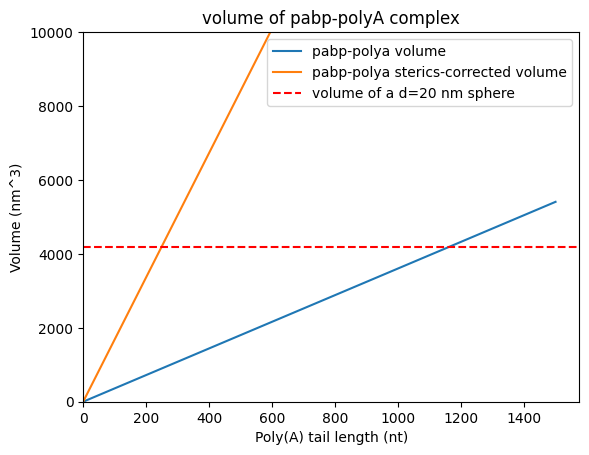

In [11]:
##before we do anything, just a quick thing to see how much polya-pabp could fit in a 20-nm-diameter globule.
import matplotlib.pyplot as plt
import numpy as np

v_pabp = (0.73e21/6.023e23) * 32750 #nm^3. pabpn1 is ~32.75 kDa.
v_pabp_sterics = v_pabp*5 # arbitrary. we spose on average, pabp in effect takes up 5x the volume bc of sterics, repulsion, ...
v_nt = 0.3   # nm^3 per nucleotide
nt_per_pabp = 12 #pabp footprint
v_max_globule = (4/3)*np.pi*(10**3) # Volume of a 21nm sphere

tail_lengths = np.arange(0, 1500, 1)
total_volumes = []
total_volumes_sterics = []
full_point = None
full_point_sterics = None

for n in tail_lengths:
    num_pabps = n / nt_per_pabp
    v_total = (n * v_nt) + (num_pabps * v_pabp)
    total_volumes.append(v_total)

    if v_total >= v_max_globule and full_point is None:
        full_point = n

    v_total_sterics = (n * v_nt) + (num_pabps * v_pabp_sterics)
    total_volumes_sterics.append(v_total_sterics)

    if v_total_sterics >= v_max_globule and full_point_sterics is None:
        full_point_sterics = n

plt.figure()
plt.plot(tail_lengths, total_volumes, label='pabp-polya volume')
plt.plot(total_volumes_sterics, label='pabp-polya sterics-corrected volume')
plt.axhline(y=v_max_globule, linestyle = '--', color = 'red', label='volume of a d=20 nm sphere ')
plt.title("volume of pabp-polyA complex")
plt.xlabel("Poly(A) tail length (nt)")
plt.ylabel("Volume (nm^3)")
plt.legend()
plt.ylim(0,10000)
plt.xlim(0)

print(f"globule volume is totally full at {full_point} nt and {full_point/nt_per_pabp} PABPs.")
print(f"with arbitrary sterics factor that multiplies the 'effective' pabp volume by 5, globule volume is full at {full_point_sterics} nt and {full_point_sterics/nt_per_pabp} PABPs.")

## v1 an initial attempt
to study the energy of a loop of n number of A's, imposing 1) the energy of forcing a polymer with a particular end-to-end distance to circularize (MacKintosh semiflexible fiber model), and 2) the bending rigidity (dependent on the persistence length, which we suppose is increased as PABP packs on the polyA)

i am keeping this version because (somehow) bending energy of a pabp-coated polya equals the 'energy to circularize' a pabp-coated polya at precisely 250 nt....(on the first run! wat???)

v_pabp = 39.69367424871327
r_pabp = 2.1161391921552135
250
18.997715101568716


/tmp/ipykernel_12407/3311025015.py:64: RuntimeWarning: divide by zero encountered in log
  G_loop_coated = -kbT * np.log(p_loop_coated)


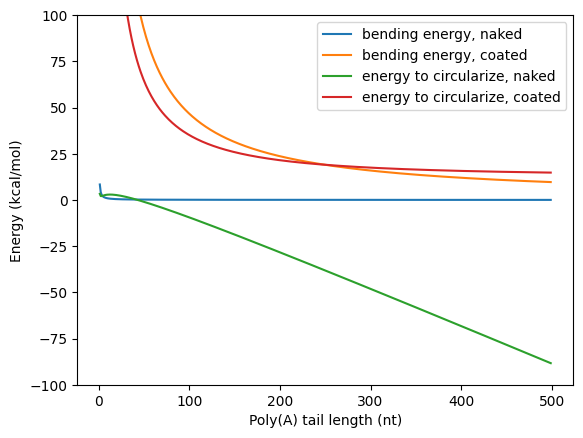

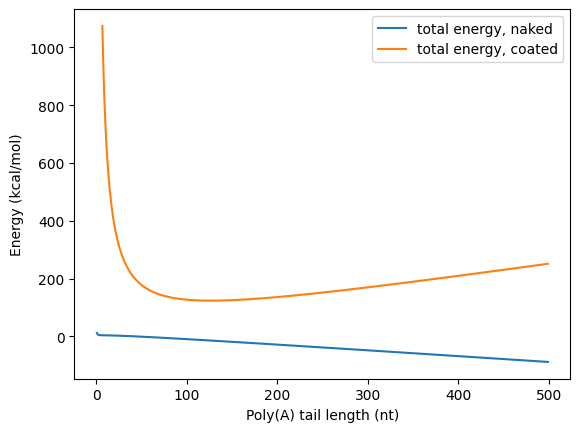

In [ ]:
##v1
#goal- energy cost of adding PABPs into a circle, only considering bending energy and entropy costs of circularization.

import numpy as np
import matplotlib.pyplot as plt

#constants
v_pabp = (0.73e21/6.023e23) * 32750 #nm^3. pabpn1 is ~32.75 kDa.
r_pabp = (3*v_pabp/4/np.pi)**(1/3) #nm
print(f"v_pabp = {v_pabp}")  ####cross-check.
print(f"r_pabp = {r_pabp}")
d_nt = 2.6 + 0.34/2 #nm. nt is ~2.6 nm, distance bw adjacent nt ~0.34 nm.
num_A = np.arange(1, 500, 1)
nt_per_pabp = 11 #pabp(n1) footprint

# v_max_globule = 4/3*np.pi*(10)**3 #r = 10 nm. dont need this for now.

l_p_naked = 2 #persistence length in nm for ssRNA
stiff_pabp = 1000 #some stiffness factor when pabp binds (increasing l_p)
l_p_coated = l_p_naked + stiff_pabp

E_binding_all = [] #to collect gains from pabp binding.
E_bend_naked_all = [] #to consider first bending E of naked polya
E_bend_coated_all = [] #bending E of polya coated in pabp.
G_loop_naked_all = []  #energy of circularizing a naked polya... not too bad
G_loop_coated_all = [] #energy of circularizing a pabp-coated polya...


###################################
for n in num_A:
  length_polya = n*d_nt #this is simply the circumference 2pi*r, so
  r = length_polya/2/np.pi

  ##enthalpic gains of PABP binding (only for coated)
  energy_per_pabp = -5
  num_pabp = n/nt_per_pabp
  E_binding = energy_per_pabp*num_pabp
  E_binding_all.append(E_binding)

  #enthalpic gains of PABP-PABP self-associating
  h_pabp_polya = -0.5*n # pabp binds polyA with a Kd in the uM-nM range.
  # extra gains for loops that linear won't get:
  h_pabp_self = -70 # pabp has self-interacting domains. we only grant this gain for loops.
  h_pap_mpsf = -50 # pap has an RNA-independent, structurally solved binding interface with mPSF.

  ##bending energy will drop since r is increasing..
  bend_stiff_n = l_p_naked*4.1 #(k_B)*T = 4.1 pN nm at RT, the bending rigidity.
  E_bend_naked = ((np.pi*bend_stiff_n)/r)*0.143 #we approx. as pi*kappa/r.
      ####see histone-wrapped DNA example!
      #the *0.143 is to convert pN*nm to kcal/mol.
  E_bend_naked_all.append(E_bend_naked)

  bend_stiff_c = l_p_coated*4.1 + (100*np.log(n+1)) #factor in slight PABP cooperativity that "worsens" the stiffen even more.
        #####kind of arbitrary. improve.
  E_bend_coated = ((np.pi*bend_stiff_c)/r)*0.143
  E_bend_coated_all.append(E_bend_coated)

  ##at the same time, we incur an entropic cost of bringing the ends together of an increasingly long chain:
      ##probability that the 2 ends find each other scales with length_polya**(-3/2).
  kbT = 0.616 #kcal/mol
  lam_naked = length_polya/l_p_naked
  W_0 = (1 / l_p_naked**3) * (89.6 / lam_naked**5) * np.exp(-14.05 / lam_naked + 0.246 * lam_naked)
        #######shimada-yamakawa approx...... IDK what this
  p_loop_naked = W_0 * v_pabp ##unitless probability
  G_loop_naked = -kbT * np.log(p_loop_naked)
  G_loop_naked_all.append(G_loop_naked)

  lam_coated = length_polya/l_p_coated
  W_0 = (1 / l_p_coated**3) * (89.6 / lam_coated**5) * np.exp(-14.05 / lam_coated + 0.246 * lam_coated)
  p_loop_coated = W_0 * v_pabp
  G_loop_coated = -kbT * np.log(p_loop_coated)
  G_loop_coated_all.append(G_loop_coated)

plt.figure()
plt.plot(num_A, E_bend_naked_all, label = 'bending energy, naked')
plt.plot(num_A, E_bend_coated_all, label = 'bending energy, coated')
plt.plot(num_A, G_loop_naked_all, label = 'energy to circularize, naked')
plt.plot(num_A, G_loop_coated_all, label = 'energy to circularize, coated')
plt.legend()
plt.xlabel('Poly(A) tail length (nt)')
plt.ylabel('Energy (kcal/mol)')
plt.ylim(-100,100)

#find where the coated-polya bending energy equals its energy of circularizing
E_bend_coated_all = np.array(E_bend_coated_all)
G_loop_coated_all = np.array(G_loop_coated_all)
start_index = 50
diff = np.abs(E_bend_coated_all[start_index:]- G_loop_coated_all[start_index:])
idx = np.argmin(diff) + start_index
n_intersection = num_A[idx]
energy_at_intersection = E_bend_coated_all[idx]
print(n_intersection)
print(energy_at_intersection)


############################
# the above is clunky, and now we should plot *net* energies, considering enthalpy of pabp-polya binding.
G_tot_naked = np.array(G_loop_naked_all) + np.array(E_bend_naked_all)
G_tot_coated = np.array(G_loop_coated_all) + np.array(E_bend_coated_all) - np.array(E_binding_all)
plt.figure()
plt.plot(num_A, G_tot_naked, label = 'total energy, naked')
plt.plot(num_A, G_tot_coated, label = 'total energy, coated')
plt.legend()
plt.xlabel('Poly(A) tail length (nt)')
plt.ylabel('Energy (kcal/mol)')

###################################################################
#now update the l_p's to consider electrostatic screening.
  #we use odijk-skolnick-fixman (OSF) theory, generally valid >100 mM.
salt_conc = np.arange(0.01, 0.3, 0.01) #M
for n in salt_conc:
  salt = n
  debye_length = 0.304 / np.sqrt(salt)
  l_p_naked_salt = l_p_naked + debye_length
  l_p_coated_salt = l_p_coated + debye_length


## v2
we organize to follow structure in summary.md

v_pabp = 39.69367424871327
r_pabp = 2.1161391921552135
250
18.997715101568716


/tmp/ipykernel_3235/1219375767.py:64: RuntimeWarning: divide by zero encountered in log
  G_loop_coated = -kbT * np.log(p_loop_coated)


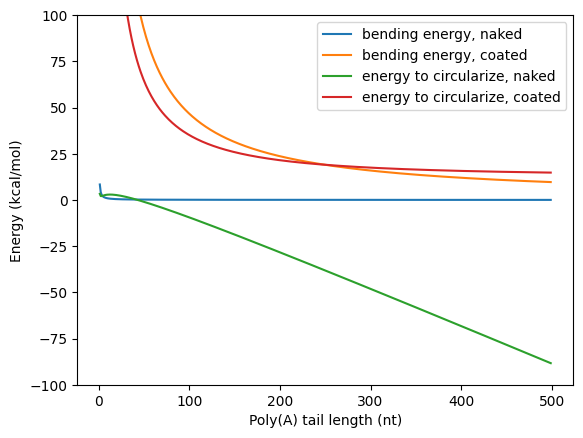

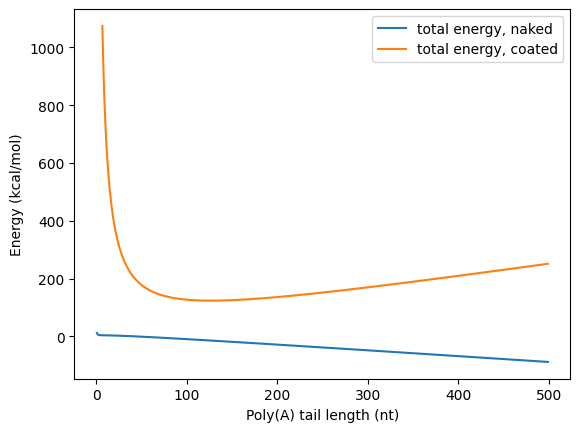

In [1]:
## v2

import numpy as np
import matplotlib.pyplot as plt

#constants
v_pabp = (0.73e21/6.023e23) * 32750 #nm^3. pabpn1 is ~32.75 kDa.
r_pabp = (3*v_pabp/4/np.pi)**(1/3) #nm
print(f"v_pabp = {v_pabp}")  ####cross-check.
print(f"r_pabp = {r_pabp}")
d_nt = 2.6 + 0.34/2 #nm. nt is ~2.6 nm, distance bw adjacent nt ~0.34 nm.
num_A = np.arange(1, 500, 1)
nt_per_pabp = 11 #pabp(n1) footprint

# enthalpy of binding
h_pabp_polya = -0.5*(n/pabp_footprint) # pabp binds polyA with a Kd in the uM-nM range.
# extra gains for loops that lin (linear) won't get:
h_pabp_self = -2*(n/pabp_footprint) # pabp has self-interacting domains. we only grant this gain for loops.
h_pap_mpsf = -5 # pap has an RNA-independent, structurally solved binding interface with mPSF.

# v_max_globule = 4/3*np.pi*(10)**3 #r = 10 nm. dont need this for now.

l_p_naked = 2 #persistence length in nm for ssRNA
stiff_pabp = 1000 #some stiffness factor when pabp binds (increasing l_p)
l_p_coated = l_p_naked + stiff_pabp

E_binding_all = [] #to collect gains from pabp binding.
E_bend_naked_all = [] #to consider first bending E of naked polya
E_bend_coated_all = [] #bending E of polya coated in pabp.
G_loop_naked_all = []  #energy of circularizing a naked polya... not too bad
G_loop_coated_all = [] #energy of circularizing a pabp-coated polya...


###################################
for n in num_A:
  length_polya = n*d_nt #this is simply the circumference 2pi*r, so
  r = length_polya/2/np.pi

  ##enthalpic gains of PABP binding.
  energy_per_pabp = -5
  num_pabp = n/nt_per_pabp
  E_binding = energy_per_pabp*num_pabp
  E_binding_all.append(E_binding)

  ##bending energy will drop since r is increasing..
  bend_stiff_n = l_p_naked*4.1 #(k_B)*T = 4.1 pN nm at RT, the bending rigidity.
  E_bend_naked = ((np.pi*bend_stiff_n)/r)*0.143 #we approx. as pi*kappa/r.
      ####see histone-wrapped DNA example!
      #the *0.143 is to convert pN*nm to kcal/mol.
  E_bend_naked_all.append(E_bend_naked)

  bend_stiff_c = l_p_coated*4.1 + (100*np.log(n+1)) #factor in slight PABP cooperativity that "worsens" the stiffen even more.
        #####kind of arbitrary. improve?
  E_bend_coated = ((np.pi*bend_stiff_c)/r)*0.143
  E_bend_coated_all.append(E_bend_coated)

  ##at the same time, we incur an entropic cost of bringing the ends together of an increasingly long chain:
      ##probability that the 2 ends find each other scales with length_polya**(-3/2).
  kbT = 0.616 #kcal/mol
  lam_naked = length_polya/l_p_naked
  W_0 = (1 / l_p_naked**3) * (89.6 / lam_naked**5) * np.exp(-14.05 / lam_naked + 0.246 * lam_naked)
        #######shimada-yamakawa approx...... IDK what this
  p_loop_naked = W_0 * v_pabp ##unitless probability
  G_loop_naked = -kbT * np.log(p_loop_naked)
  G_loop_naked_all.append(G_loop_naked)

  lam_coated = length_polya/l_p_coated
  W_0 = (1 / l_p_coated**3) * (89.6 / lam_coated**5) * np.exp(-14.05 / lam_coated + 0.246 * lam_coated)
  p_loop_coated = W_0 * v_pabp
  G_loop_coated = -kbT * np.log(p_loop_coated)
  G_loop_coated_all.append(G_loop_coated)

plt.figure()
plt.plot(num_A, E_bend_naked_all, label = 'bending energy, naked')
plt.plot(num_A, E_bend_coated_all, label = 'bending energy, coated')
plt.plot(num_A, G_loop_naked_all, label = 'energy to circularize, naked')
plt.plot(num_A, G_loop_coated_all, label = 'energy to circularize, coated')
plt.legend()
plt.xlabel('Poly(A) tail length (nt)')
plt.ylabel('Energy (kcal/mol)')
plt.ylim(-100,100)

#find where the coated-polya bending energy equals its energy of circularizing
E_bend_coated_all = np.array(E_bend_coated_all)
G_loop_coated_all = np.array(G_loop_coated_all)
start_index = 50
diff = np.abs(E_bend_coated_all[start_index:]- G_loop_coated_all[start_index:])
idx = np.argmin(diff) + start_index
n_intersection = num_A[idx]
energy_at_intersection = E_bend_coated_all[idx]
print(n_intersection)
print(energy_at_intersection)


############################
#now compute the G_loop. we have to add in the gains- H_pabp-pabp, H_pabp-mpsf, H_pabp-polya
h_pabp_polya = -0.5*n # pabp binds polyA with a Kd in the uM-nM range.
G_tot_naked = np.array(G_loop_naked_all) + np.array(E_bend_naked_all)
G_tot_coated = np.array(G_loop_coated_all) + np.array(E_bend_coated_all) - np.array(E_binding_all)



###################################################################
#now update the l_p's to consider electrostatic screening.
  #we use odijk-skolnick-fixman (OSF) theory, generally valid >100 mM.
salt_conc = np.arange(0.01, 0.3, 0.01) #M
for n in salt_conc:
  salt = n
  debye_length = 0.304 / np.sqrt(salt)
  l_p_naked_salt = l_p_naked + debye_length
  l_p_coated_salt = l_p_coated + debye_length


In [ ]:
# note, we will try to compare a naked polyA RNA with a pabp-coated polyA RNA,
  # so do calcs twice. n, naked. c, coated.

import numpy as np
import matplotlib.pyplot as plt
import math

# constants
k_B = 1.38064852e-23 #m^2 kg s^-2 K^-1. equal to 4.1 pN*nm
# constants for a SAW on a cubic lattice
a = 1.5
b = 0
c = 1.77
# info about our protein and Rna.
d_nt = 2.6 + 0.34/2 #nm. nt is ~2.6 nm, distance bw adjacent nt ~0.34 nm.
pabp_footprint = 11 #nt

# persistence length and rxn conditions
l_p_n = 2 # nm
T = 310 # we run polyadenylation reactions at 37 C = 310 K.
salt = np.arange(0.01, 3) ##let's not try to explicitly model this for now.
      #we just spose salt influences stopping point insofar as it influences l_p.

tail_length = np.arange(1, 600)

e_tot_n_loop_all = []
e_tot_n_lin_all = []
e_tot_c_loop_all = []
e_tot_c_lin_all = []

for n in tail_length:
  length_polya = n*d_nt #this is simply the circumference 2pi*r, so
  r = length_polya/2/np.pi
  l_p_c = 2 + (100*np.log(n+1)) # we imagine the stiffness grows w
    #### is there a way to derive this modeling pabp's as spheres?

# energy terms
  # enthalpy of binding
  h_pabp_polya = -0.5*(n/pabp_footprint) # pabp binds polyA with a Kd in the uM-nM range.
  # extra gains for loops that lin (linear) won't get:
  h_pabp_self = -2*(n/pabp_footprint) # pabp has self-interacting domains. we only grant this gain for loops.
  h_pap_mpsf = -5 # pap has an RNA-independent, structurally solved binding interface with mPSF.

# energy of bending
  bending_rigidity_n = l_p_n*4.1 #(k_B)*T = 4.1 pN nm at RT, the bending rigidity.
  bending_rigidity_c = l_p_c*4.1
  e_bend_n = ((np.pi*bending_rigidity_n)/r)*0.143 #we approx. as pi*kappa/r.
      #the *0.143 is to convert pN*nm to kcal/mol.
  e_bend_c = ((np.pi*bending_rigidity_c)/r)*0.143

# entropy
  s_loop = 0.001987*(n*a - b + c*(math.log(n)))
  s_lin = 0.001987*(n*a - b)

  # sums
  e_tot_n_loop = e_bend_n + h_pap_mpsf - T*(s_loop)
  e_tot_n_lin = h_pabp_polya - T*(s_lin)
  e_tot_c_loop = e_bend_n + h_pabp_polya + h_pabp_self + h_pap_mpsf - T*(s_loop)
  e_tot_c_lin = h_pabp_polya + h_pabp_polya - T*(s_lin)

  e_tot_n_loop_all.append(e_tot_n_loop)
  e_tot_n_lin_all.append(e_tot_n_lin)
  e_tot_c_loop_all.append(e_tot_c_loop)
  e_tot_c_lin_all.append(e_tot_c_lin)

# plot energies
plt.figure()
plt.plot(tail_length, e_tot_n_loop_all, label = 'naked loop')
plt.plot(tail_length, e_tot_n_lin_all, label = 'naked linear')
plt.plot(tail_length, e_tot_c_loop_all, label = 'coated loop')
plt.plot(tail_length, e_tot_c_lin_all, label = 'coated linear')
plt.legend()
plt.xlabel('number of A\'s')
plt.ylabel('energy (kcal/mol)')


# plot globule OR filament tendency



the persistence length L_p of an uncooked spaghetti [noodle](https://en.wikipedia.org/wiki/Persistence_length) is 10^18 m, which means that it would take a length of 10^18 m for thermal fluctuations at 300K to allow it to bend.

the persistence length of ssRNA is 1-6 nm or 10-60 A which is around 60/3 = 20 nt (this is not right. check.), which means that it's not really a problem for the RNA to be bending as it's being ejected from PAP. however, if PABPs are packing on, then the persistence length of the *PABP-RNA complex* is probably super high. The L_p of a dsRNA is around 100-600 A.

**what is the L_p of a PABP-RNA complex?**

for charged polymers, the L_p depends on salt concentration due to electrostatic screening...

at higher salt, a negatively charged polymer is more neutralized and so experiences less self-repulsion. ***so it can probably be more bendy!*** ie, decreased L_p.

**how does salt influence L_p?**

In [ ]:
#goal- plot persistence length of polyrA as a function of salt conc.


#if it's decreased, then less resistance to adenylating in a circle...
#so the processive phase is facilitated, and possibly distributive phase too


##at what point does increasing salt no longer decrease L_p?
###test this salt conc then test past it to see if no longer increase tail length

In [ ]:
#goal- see how PABP binding influences persistence length of polyrA

**during processive burst, has pabp arrived on scene yet?**

what if pabp binds slower than the burst, so that by the time it does bind, it stiffens the polymer sufficiently to spring it open?

In [ ]:

#goal- compute energies of the following polyrA-PABP complexes:
  #An, n*11 number of A's in polyrA. Bm, m number of PABPs.
#A1B1
#A2B2
#...
#A20-B20

##when are n and m different? n > m when...
  #the latest binding site hasn't finished being synthesized (<11 new A's)
  #the speed of

k_on_intr = 2*10^-6 #M^{-1}s^{-1} #determined, meyer2002
k_off_intr = ??? #M^{-1}s^{-1}



In [ ]:
#goal- make A loop with equivalent binding strength as PAP-mPSF interaction.
#deltaG = RTlnKd


## more background
* The Lennard-Jones (LJ) 12-6 [potential](https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Supplemental_Modules_(Physical_and_Theoretical_Chemistry)/Physical_Properties_of_Matter/Atomic_and_Molecular_Properties/Intermolecular_Forces/Specific_Interactions/Lennard-Jones_Potential) simply describes the essential features of particles interacting: too close, they repel; moderate distances, they attract; above that, no more interaction. The Rosetta energy function uses it to describe VDW interactions.
* Jacobson-Stockmayer ([1950](https://ui.adsabs.harvard.edu/abs/1950JChPh..18.1600J/abstract#:~:text=Stockmayer%2C%20Walter%20H.-,Abstract,AIP)) describe equilibrium between linear and cyclic polymer chains (formed by 'back-biting') in polycondensation systems.

# todo
* self-avoiding walks with self-attraction? --> maybe can remove enthalpy terms for pabp-pabp self-interaction

### notes
* pabp initially stimulates PAP (perhaps not by 'stimulating' PAP activity per se, but b/c it self-associates and therefore reduces the entropic penalty of bringing the ends together in a loop, allowing PAP to maintain favorable contact with mPSF)... but ultimately arrests the process.
* a similar bursty process- transcription- has been described similarly to arise from RNA (charge)-mediated feedback control in Henninger et al.'s 2021 paper, RNA-mediated feedback of transcriptional condensates.